## Module_3: *(Template)*

## Team Members:
*(Fill in)*

## Project Title:
*(Fill in)*



## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## Disease Background: 
*Fill in information and please note that this module is truncated and only has 5 bullets (instead of the 11 that you did for Module #1).*

* Prevalence & incidence
* Risk factors (genetic, lifestyle)
* Symptoms
* Standard of care treatment(s)
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

## Data-Set: 
*Describe the data set(s) you will analyze. Cite the source(s) of the data -- in this case, these data have not yet been published and they are "hot off the press", having been recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab (https://uvahealth.com/findadoctor/John-Kim-1407155682) in the Division of Pulmonary and Critical Care at UVA. So the proper way to cite these data is:

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*



### Import Packages

In [3]:
from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd

### Open Selected Images
Below are the 6 images we chose to analyze from the complete set of phots we were given

In [4]:
filenames = [
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010017.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010018.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010019.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010022.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg",
]

### Gather Data

The code below counts the pixels in each image for the specified depth

In [11]:
# Depths (microns)
depths = [15, 30, 45, 55, 60, 80]

white_counts = []
black_counts = []
white_percents = []

print(colored("Counts of pixels by color in each image", "yellow"))

for filename, depth in zip(filenames, depths):

    # Load image in grayscale
    img = cv2.imread(filename, 0)

    # Binary threshold
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Pixel counts
    white = np.count_nonzero(binary)
    total = binary.size
    black = total - white

    # Percent white
    white_percent = 100 * white / total

    # Store values
    white_counts.append(white)
    black_counts.append(black)
    white_percents.append(white_percent)

    # Print results
    print(colored(f"{filename}:", "red"))
    print(colored(f"White pixels: {white}", "white"))
    print(colored(f"Black pixels: {black}", "blue"))
    print(f"{white_percent:.2f}% White | Depth: {depth} microns\n")

# Save results to CSV
df = pd.DataFrame({
    "Filename": filenames,
    "Depth (microns)": depths,
    "White Percent": white_percents
})

df.to_csv("Percent_White_Pixels.csv", index=False)

print("CSV file 'Percent_White_Pixels.csv' created.")



Counts of pixels by color in each image
C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010017.jpg:
White pixels: 27561
Black pixels: 4166743
0.66% White | Depth: 15 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010018.jpg:
White pixels: 33746
Black pixels: 4160558
0.80% White | Depth: 30 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010019.jpg:
White pixels: 31331
Black pixels: 4162973
0.75% White | Depth: 45 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg:
White pixels: 23900
Black pixels: 4170404
0.57% White | Depth: 55 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010022.jpg:
White pixels: 33151
Black pixels: 4161153
0.79% White | Depth: 60 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg:
Whi

### Linear Interpolation:
Because the minimum depth is 15 and the max is 80, the value to interpolate must be between these two.


Linear interpolation at depth 50.0: 0.658% white



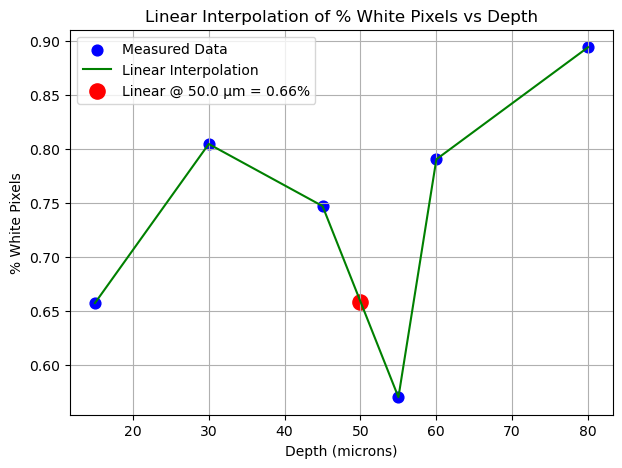

In [20]:
# LOAD YOUR DATA
df = pd.read_csv("Percent_White_Pixels.csv")
x = df["Depth (microns)"].tolist()
y = df["White Percent"].tolist()


# USER INPUT
interp_depth = float(input("Enter the depth at which you want to interpolate (microns): "))


# LINEAR INTERPOLATION
linear_f = interp1d(x, y, kind='linear')
linear_value = float(linear_f(interp_depth))
linear_value = max(0, min(100, linear_value))
print(f"\nLinear interpolation at depth {interp_depth}: {linear_value:.3f}% white\n")


# PLOT: LINEAR INTERPOLATION
plt.figure(figsize=(7,5))

# Plot original data
plt.scatter(x, y, color='blue', s=60, label='Measured Data')

# Plot linear interpolation line
x_line = np.linspace(min(x), max(x), 300)
y_line = linear_f(x_line)
plt.plot(x_line, y_line, color='green', label='Linear Interpolation')

# Plot interpolated point
plt.scatter(interp_depth, linear_value, color='red', s=120, label=f'Linear @ {interp_depth} µm = {linear_value:.2f}%')
plt.title("Linear Interpolation of % White Pixels vs Depth")
plt.xlabel("Depth (microns)")
plt.ylabel("% White Pixels")
plt.grid(True)
plt.legend()
plt.show()

### Quadratic Interpolation

Because the minimum depth is 15 and the max is 80, the value to interpolate must be between these two.



Quadratic interpolation at depth 50.0: 0.601% white



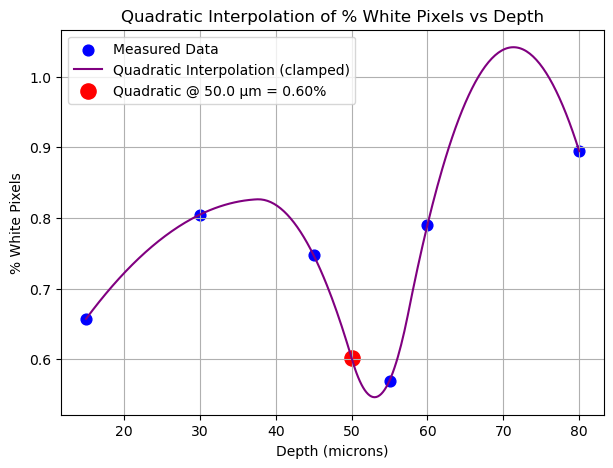

In [19]:
# LOAD YOUR DATA
df = pd.read_csv("Percent_White_Pixels.csv")
x = df["Depth (microns)"].tolist()
y = df["White Percent"].tolist()

interp_depth = float(input("Enter the depth at which you want to interpolate (microns): "))

# QUADRATIC INTERPOLATION (SciPy spline)
quad_f = interp1d(x, y, kind='quadratic')

quad_value = float(quad_f(interp_depth))
quad_value = max(0, min(100, quad_value))   # clamp

print(f"\nQuadratic interpolation at depth {interp_depth}: {quad_value:.3f}% white\n")

plt.figure(figsize=(7,5))

plt.scatter(x, y, color='blue', s=60, label='Measured Data')

x_line = np.linspace(min(x), max(x), 300)
y_line = quad_f(x_line)
y_line = np.clip(y_line, 0, 100)            # clamp curve

plt.plot(x_line, y_line, color='purple', label='Quadratic Interpolation (clamped)')

plt.scatter(interp_depth, quad_value, color='red', s=120,
            label=f'Quadratic @ {interp_depth} µm = {quad_value:.2f}%')

plt.title("Quadratic Interpolation of % White Pixels vs Depth")
plt.xlabel("Depth (microns)")
plt.ylabel("% White Pixels")
plt.grid(True)
plt.legend()
plt.show()

### Cubic Interpolation


Cubic (3rd-degree) interpolation at depth 50.0: 0.603% white



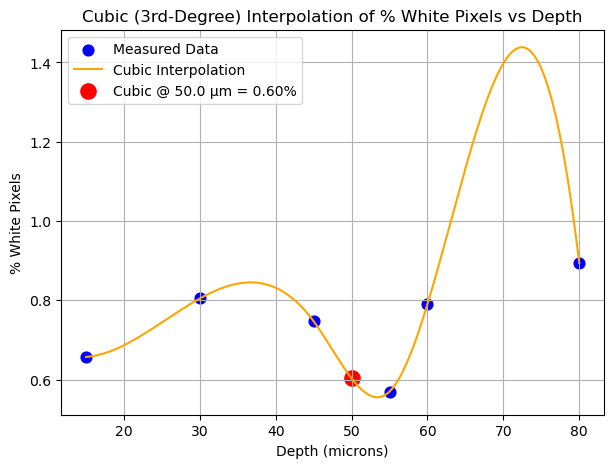

In [21]:
# LOAD YOUR DATA
df = pd.read_csv("Percent_White_Pixels.csv")
x = df["Depth (microns)"].tolist()
y = df["White Percent"].tolist()


# USER INPUT
interp_depth = float(input("Enter the depth at which you want to interpolate (microns): "))


# CUBIC (3rd-degree) INTERPOLATION
cubic_f = interp1d(x, y, kind='cubic')
cubic_value = float(cubic_f(interp_depth))
print(f"\nCubic (3rd-degree) interpolation at depth {interp_depth}: {cubic_value:.3f}% white\n")


# PLOT: CUBIC INTERPOLATION
plt.figure(figsize=(7,5))

# Plot original measured data
plt.scatter(x, y, color='blue', s=60, label='Measured Data')

# Plot cubic interpolation curve
x_line = np.linspace(min(x), max(x), 300)
y_line = cubic_f(x_line)
plt.plot(x_line, y_line, color='orange', label='Cubic Interpolation')

# Plot interpolated point
plt.scatter(interp_depth, cubic_value, color='red', s=120, label=f'Cubic @ {interp_depth} µm = {cubic_value:.2f}%')
plt.title("Cubic (3rd-Degree) Interpolation of % White Pixels vs Depth")
plt.xlabel("Depth (microns)")
plt.ylabel("% White Pixels")
plt.grid(True)
plt.legend()
plt.show()

## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References:
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*